In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("cleaned_ebay_deals.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.sort_values("timestamp")
df["hour"] = df["timestamp"].dt.hour
df["price_difference"] = df["original_price"] - df["price"]

df.head()

,timestamp,title,price,original_price,shipping,item_url,discount_percentage,hour,price_difference
0,2026-03-10 12:12:58,Lenovo M920q TINY / i5 8th / PICK YOUR RAM / P...,221.00,221.00,Shipping info unavailable,https://www.ebay.com/itm/256232862651?_trkparm...,0.00,12,0.00
60,2026-03-10 12:12:58,Jensen Transformers CI-2MINI Hum/Buzz Eliminat...,239.99,239.99,Shipping info unavailable,https://www.ebay.com/itm/400279054316?_trkparm...,0.00,12,0.00
59,2026-03-10 12:12:58,AM Transmitter - Stream to Your Vintage Tube R...,49.95,49.95,Shipping info unavailable,https://www.ebay.com/itm/146862567086?_trkparm...,0.00,12,0.00
58,2026-03-10 12:12:58,K&F Concept adapter with tripod for Nikon F mo...,23.91,25.99,Shipping info unavailable,https://www.ebay.com/itm/272897136665?_trkparm...,8.00,12,2.08
57,2026-03-10 12:12:58,CANON RF-S10-18mm F4.5-6.3 IS STM Ultra Wide Z...,167.20,311.25,Shipping info unavailable,https://www.ebay.com/itm/187782830629?_trkparm...,46.28,12,144.05


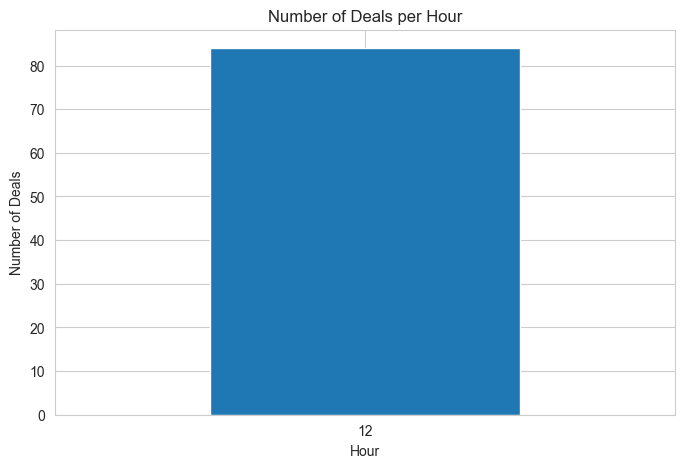

In [3]:
deals_per_hour = df.groupby("hour").size()

plt.figure(figsize=(8,5))
deals_per_hour.plot(kind="bar")
plt.title("Number of Deals per Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Deals")
plt.xticks(rotation=0)
plt.show()

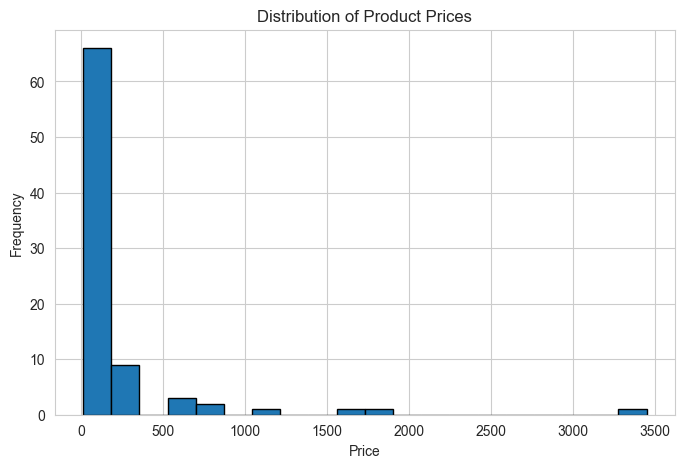

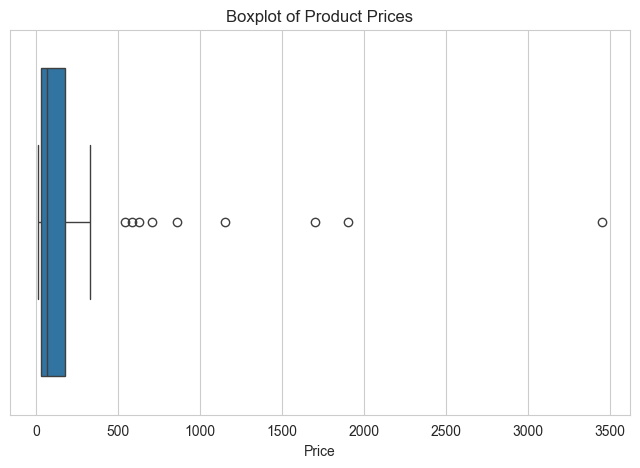

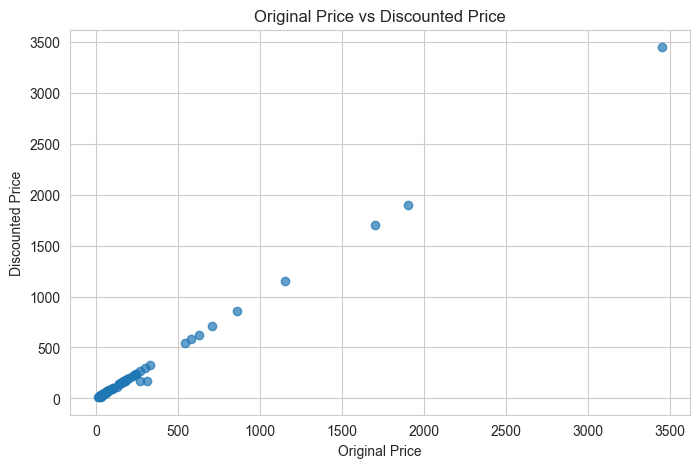

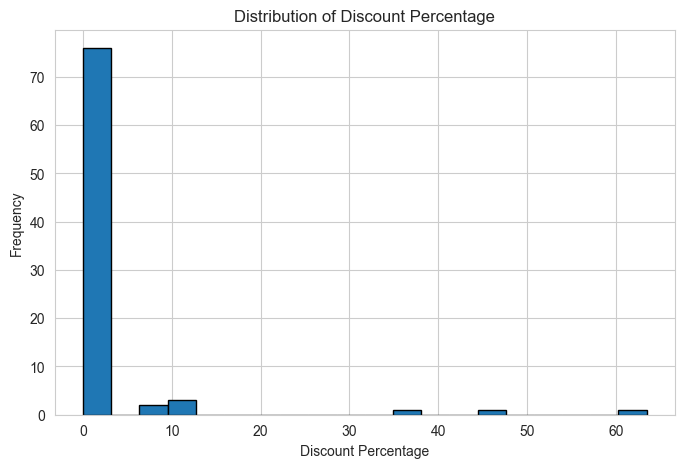

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df["price"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Product Prices")
plt.xlabel("Price")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["original_price"], df["price"], alpha=0.7)
plt.title("Original Price vs Discounted Price")
plt.xlabel("Original Price")
plt.ylabel("Discounted Price")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["discount_percentage"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Frequency")
plt.show()

shipping
Shipping info unavailable    84
Name: count, dtype: int64


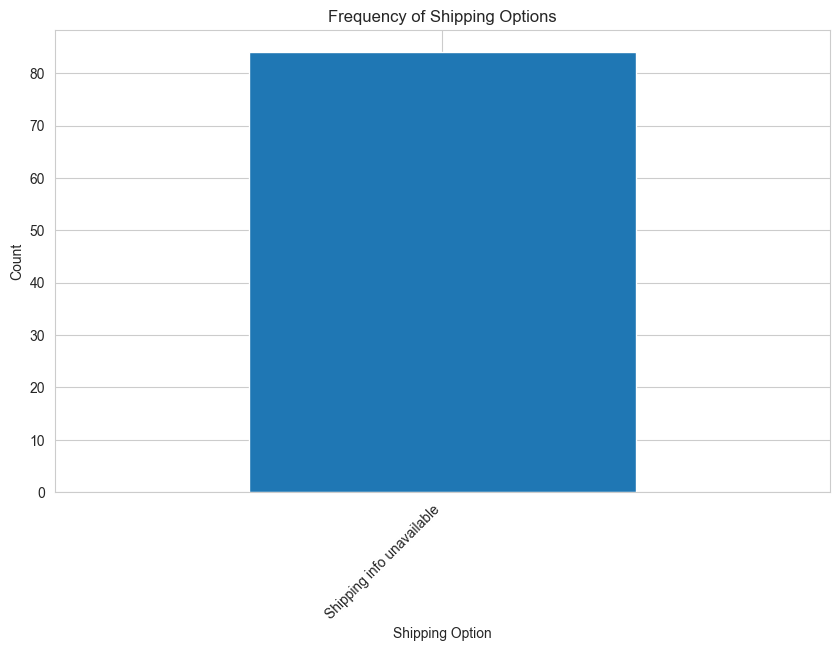

In [5]:
shipping_counts = df["shipping"].value_counts()
print(shipping_counts)

plt.figure(figsize=(10,6))
shipping_counts.plot(kind="bar")
plt.title("Frequency of Shipping Options")
plt.xlabel("Shipping Option")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

   Keyword  Count
0    Apple      6
1  Samsung      1
2   Laptop      2
3   iPhone      3
4   Tablet      2
5   Gimbal      0


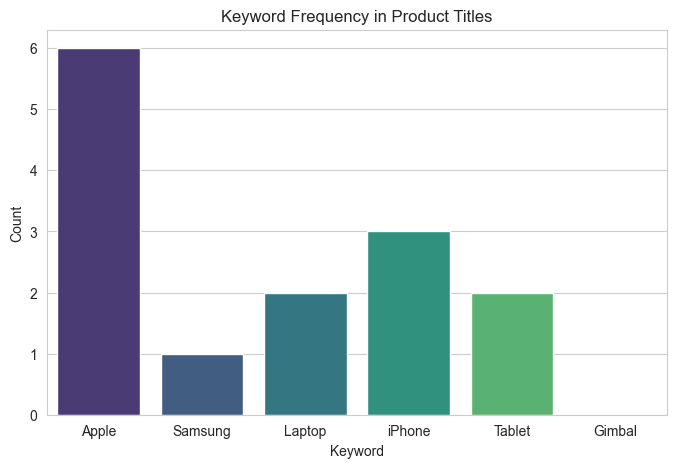

In [6]:
keywords = ["Apple", "Samsung", "Laptop", "iPhone", "Tablet", "Gimbal"]
keyword_counts = {}

for keyword in keywords:
    keyword_counts[keyword] = df["title"].str.contains(keyword, case=False, na=False).sum()

keyword_df = pd.DataFrame(list(keyword_counts.items()), columns=["Keyword", "Count"])
print(keyword_df)

plt.figure(figsize=(8,5))
sns.barplot(data=keyword_df, x="Keyword", y="Count", hue="Keyword", palette="viridis", legend=False)
plt.title("Keyword Frequency in Product Titles")
plt.xlabel("Keyword")
plt.ylabel("Count")
plt.show()

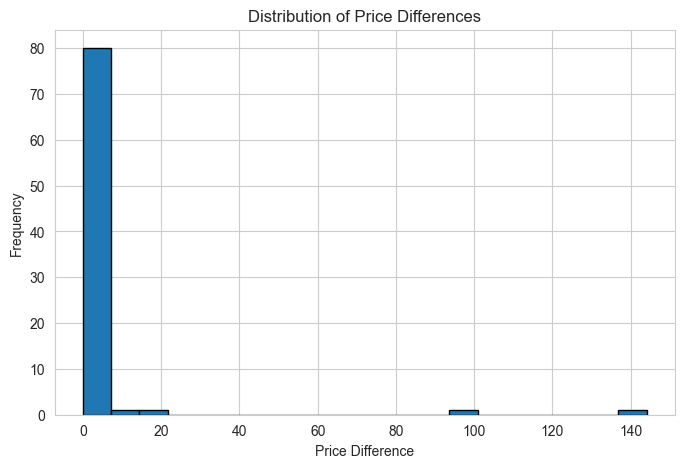

,title,price,original_price,discount_percentage,shipping
65,Married With Children ~ Complete 5th Fifth Sea...,10.95,29.95,63.44,Shipping info unavailable
57,CANON RF-S10-18mm F4.5-6.3 IS STM Ultra Wide Z...,167.20,311.25,46.28,Shipping info unavailable
38,"12"" Streaming Rear Camera Mirror with GPS Wifi...",169.47,269.00,37.00,Shipping info unavailable
73,360° Rotation Suction Cup Mount Tablet Holders...,43.99,49.99,12.00,Shipping info unavailable
19,LED-Streifen für TCL 55C815 55C815K 55C815KX1 ...,22.95,25.50,10.00,Shipping info unavailable


In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["price_difference"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Price Differences")
plt.xlabel("Price Difference")
plt.ylabel("Frequency")
plt.show()

top_5_discounts = df.sort_values("discount_percentage", ascending=False).head(5)
top_5_discounts[["title", "price", "original_price", "discount_percentage", "shipping"]]